# Loading and Displaying Data

In [1]:
import pandas as pd
real_news = pd.read_csv("C:/Users/Sanga/OneDrive/Desktop/True.csv")
print(real_news)
print("Length (rows):", len(real_news))

                                                   title  \
0      As U.S. budget fight looms, Republicans flip t...   
1      U.S. military to accept transgender recruits o...   
2      Senior U.S. Republican senator: 'Let Mr. Muell...   
3      FBI Russia probe helped by Australian diplomat...   
4      Trump wants Postal Service to charge 'much mor...   
...                                                  ...   
21412  'Fully committed' NATO backs new U.S. approach...   
21413  LexisNexis withdrew two products from Chinese ...   
21414  Minsk cultural hub becomes haven from authorities   
21415  Vatican upbeat on possibility of Pope Francis ...   
21416  Indonesia to buy $1.14 billion worth of Russia...   

                                                    text       subject  \
0      WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1      WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2      WASHINGTON (Reuters) - The special counsel inv... 

In [3]:
import pandas as pd
fake_news = pd.read_csv("C:/Users/Sanga/OneDrive/Desktop/Fake.csv")
print(fake_news)
print("Length (rows):", len(fake_news))

                                                   title  \
0       Donald Trump Sends Out Embarrassing New Year’...   
1       Drunk Bragging Trump Staffer Started Russian ...   
2       Sheriff David Clarke Becomes An Internet Joke...   
3       Trump Is So Obsessed He Even Has Obama’s Name...   
4       Pope Francis Just Called Out Donald Trump Dur...   
...                                                  ...   
23476  McPain: John McCain Furious That Iran Treated ...   
23477  JUSTICE? Yahoo Settles E-mail Privacy Class-ac...   
23478  Sunnistan: US and Allied ‘Safe Zone’ Plan to T...   
23479  How to Blow $700 Million: Al Jazeera America F...   
23480  10 U.S. Navy Sailors Held by Iranian Military ...   

                                                    text      subject  \
0      Donald Trump just couldn t wish all Americans ...         News   
1      House Intelligence Committee Chairman Devin Nu...         News   
2      On Friday, it was revealed that former Milwauk...    

# Combining and Shuffling the data

In [5]:
fake_news = pd.read_csv("C:/Users/Sanga/OneDrive/Desktop/Fake.csv")
real_news = pd.read_csv("C:/Users/Sanga/OneDrive/Desktop/True.csv")
fake_news['label'] = 0    
real_news['label'] = 1
data = pd.concat([fake_news, real_news]).sample(frac=1.0)   
data.to_csv('Combined.csv', index=False)
print("Data loaded successfully and combined CSV generated!")
data

Data loaded successfully and combined CSV generated!


,title,text,subject,date,label
1989,BREAKING: Devin Nunes Is Now The Subject Of A...,"Embattled House Intel Chairman, Devin Nunes (R...",News,"March 26, 2017",0
12346,China marks Nanjing Massacre anniversary but X...,BEIJING (Reuters) - China marked the 80th anni...,worldnews,"December 13, 2017",1
18751,DON’T TAKE YOUR KIDS TO New Orleans To Learn A...,It s a sad day in America when we allow the le...,left-news,"Apr 25, 2017",0
5457,Jeb Bush Kicks Off GOP Convention By Going Fu...,The Republican National Convention starts this...,News,"July 16, 2016",0
7866,Republicans Get Skewered On Twitter After Hil...,The Republican party has become the butt of ne...,News,"February 25, 2016",0
...,...,...,...,...,...
232,"Trump lifts refugee ban, but admissions still ...","WASHINGTON (Reuters) - In late October, Presi...",politicsNews,"December 8, 2017",1
1788,Trump open to Dreamers relief legislation with...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"September 21, 2017",1
13261,JOURNALIST SHERYL ATTKISSON: Famous DC Bureau ...,Sheryl Attkisson is a fantastic journalist who...,politics,"Aug 12, 2016",0
4569,"A Dallas Cop Just Filed Suit Against Obama, H...","A Dallas police officer, seeing red after seve...",News,"September 18, 2016",0


# Preprocess stemming Function

In [7]:
import re
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
def preprocess_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    text = [stemmer.stem(word) for word in text.split()]
    text = ' '.join(text)
    return text

# Training the Model


In [9]:
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification
if tf.test.is_gpu_available():
    device_name = tf.test.gpu_device_name()
else:
    device_name = 'CPU:0'
print('Using device:', device_name)
data = pd.read_csv('Combined.csv')
print("\nPreprocessing data...")
data['title_preprocessed'] = data['title'].apply(preprocess_text)
train_ratio = 0.64
val_ratio = 0.16
test_ratio = 0.2
print("\nSplitting Data...")
train_data = data.sample(frac=train_ratio, random_state=42)
remaining_data = data.drop(train_data.index)
val_data = remaining_data.sample(frac=val_ratio/(val_ratio+test_ratio), random_state=42)
test_data = remaining_data.drop(val_data.index)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("\nTokenizing and Converting...")
train_inputs = tokenizer(list(train_data['title_preprocessed']), truncation=True, padding='max_length', max_length=42, return_tensors='tf')
val_inputs = tokenizer(list(val_data['title_preprocessed']), truncation=True, padding='max_length', max_length=42, return_tensors='tf')
test_inputs = tokenizer(list(test_data['title_preprocessed']), truncation=True, padding='max_length', max_length=42, return_tensors='tf')
train_labels = tf.convert_to_tensor(list(train_data['label']))
val_labels = tf.convert_to_tensor(list(val_data['label']))
test_labels = tf.convert_to_tensor(list(test_data['label']))
train_token_tensors = train_inputs['input_ids']
train_segment_tensors = train_inputs['token_type_ids']
train_mask_tensors = train_inputs['attention_mask']
val_token_tensors = val_inputs['input_ids']
val_segment_tensors = val_inputs['token_type_ids']
val_mask_tensors = val_inputs['attention_mask']
test_token_tensors = test_inputs['input_ids']
test_segment_tensors = test_inputs['token_type_ids']
test_mask_tensors = test_inputs['attention_mask']
model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
print("\nCompiling Model...")
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')
model.compile(optimizer=optimizer, loss=loss, metrics=[metric])
print("\nTraining Model...")
batch_size = 64
num_epochs = 4
history = model.fit([train_token_tensors, train_segment_tensors, train_mask_tensors], train_labels, batch_size=batch_size, epochs=num_epochs, validation_data=([val_token_tensors, val_segment_tensors, val_mask_tensors], val_labels))
print("\nSaving Model...")

model.save_pretrained('/content/bertv3_model')


Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
Using device: CPU:0

Preprocessing data...

Splitting Data...

Tokenizing and Converting...



All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Compiling Model...

Training Model...
Epoch 1/4

449/449 [==============================] - 4541s 10s/step - loss: 0.1709 - accuracy: 0.9335 - val_loss: 0.1040 - val_accuracy: 0.9612
Epoch 2/4
449/449 [==============================] - 4261s 9s/step - loss: 0.0689 - accuracy: 0.9748 - val_loss: 0.0847 - val_accuracy: 0.9712
Epoch 3/4
449/449 [==============================] - 4577s 10s/step - loss: 0.0363 - accuracy: 0.9877 - val_loss: 0.0684 - val_accuracy: 0.9745
Epoch 4/4
449/449 [==============================] - 4794s 11s/step - loss: 0.0218 - accuracy: 0.9922 - val_loss: 0.0804 - val_accuracy: 0.9768

Saving Model...


# Validation

In [11]:
loss, accuracy = model.evaluate([test_token_tensors, test_segment_tensors, test_mask_tensors], test_labels, batch_size=batch_size)
print(f'Test loss: {loss * 100:.3f}%')
print(f'Test accuracy: {accuracy * 100:.3f}%')

141/141 [==============================] - 385s 3s/step - loss: 0.0880 - accuracy: 0.9759
Test loss: 8.804%
Test accuracy: 97.594%


# Using the model to predict

In [13]:
from transformers import BertTokenizer, TFBertForSequenceClassification
import tensorflow as tf
model = TFBertForSequenceClassification.from_pretrained('/content/bertv3_model')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
input_text = input("\n\nEnter News Title: ")
preprocessed_text = preprocess_text(input_text)
print("Preprocessed Text:", preprocessed_text)
inputs = tokenizer(preprocessed_text, truncation=True, padding='max_length', max_length=42, return_tensors='tf')
token_tensors = inputs['input_ids']
segment_tensors = inputs['token_type_ids']
mask_tensors = inputs['attention_mask']
predictions = model.predict([token_tensors, segment_tensors, mask_tensors])
logits = predictions.logits[0]
probabilities = tf.nn.softmax(logits)
predicted_label = tf.argmax(probabilities)
if predicted_label == 0:
    print("\n*-*-Fake News-*-*")
else:
    print("\n*-*-Real News-*-*")

print("\nProbability of being fake: {:.2%}".format(probabilities[0]))
print("Probability of being real: {:.2%}".format(probabilities[1]))

Some layers from the model checkpoint at /content/bertv3_model were not used when initializing TFBertForSequenceClassification: ['dropout_37']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/bertv3_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.




Enter News Title:  trump wants postal service to charge more


Preprocessed Text: trump want postal servic to charg more
1/1 [==============================] - 2s 2s/step

*-*-Real News-*-*

Probability of being fake: 0.02%
Probability of being real: 99.98%


# WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sanga\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


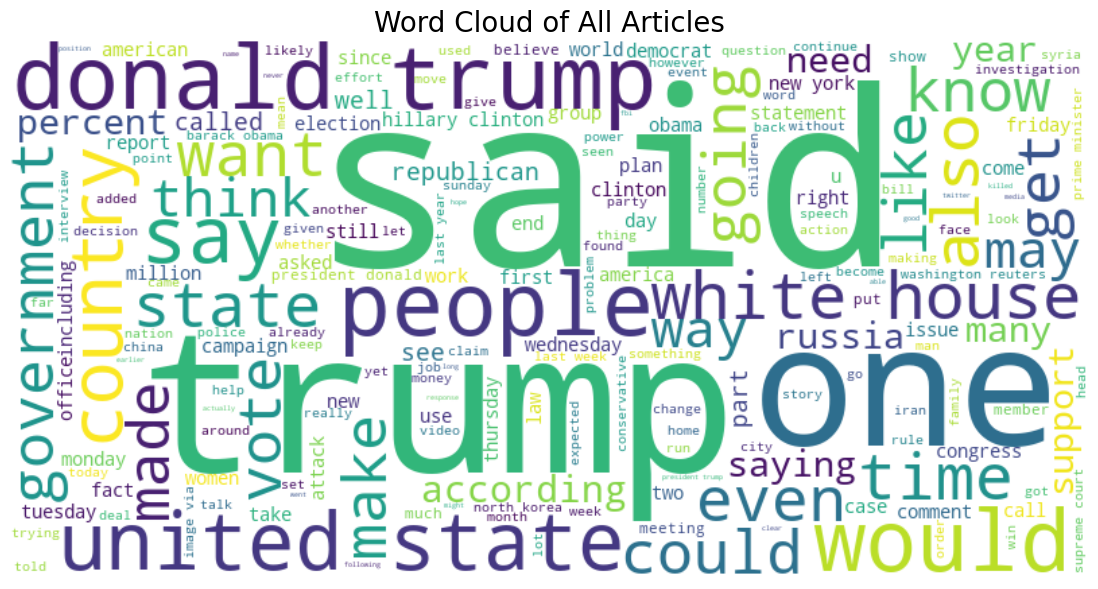

In [31]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns
import pandas as pd
import nltk
from nltk.corpus import stopwords
import re
nltk.download('stopwords')
def clean_text(text):
    text = re.sub(r"http\S+", "", text)  
    text = re.sub(r"[^A-Za-z\s]", "", text)  
    text = text.lower()
    return text
data['clean_text'] = data['text'].apply(clean_text)
all_words = ' '.join(data['clean_text'].values)
wordcloud = WordCloud(width=800, height=400, stopwords=set(stopwords.words('english')), background_color='white').generate(all_words)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of All Articles", fontsize=20)
plt.show()

# Class Distribution

C:\Users\Sanga\AppData\Local\Temp\ipykernel_6584\3178388667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='Set2')
C:\Users\Sanga\anaconda3\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Sanga\anaconda3\Lib\site-packages\seaborn\categorical.py:1280: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to sile

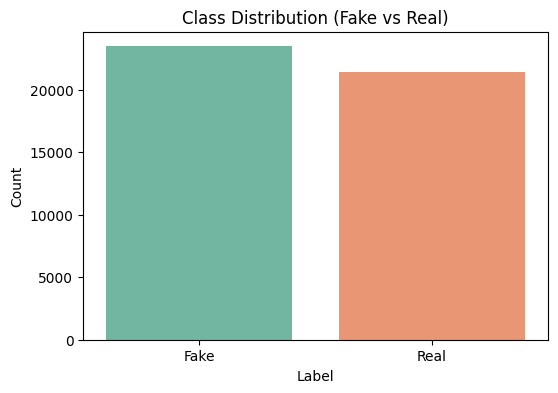

In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data, palette='Set2')
plt.title("Class Distribution (Fake vs Real)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=['Fake', 'Real'])
plt.show()

# Scores of top words

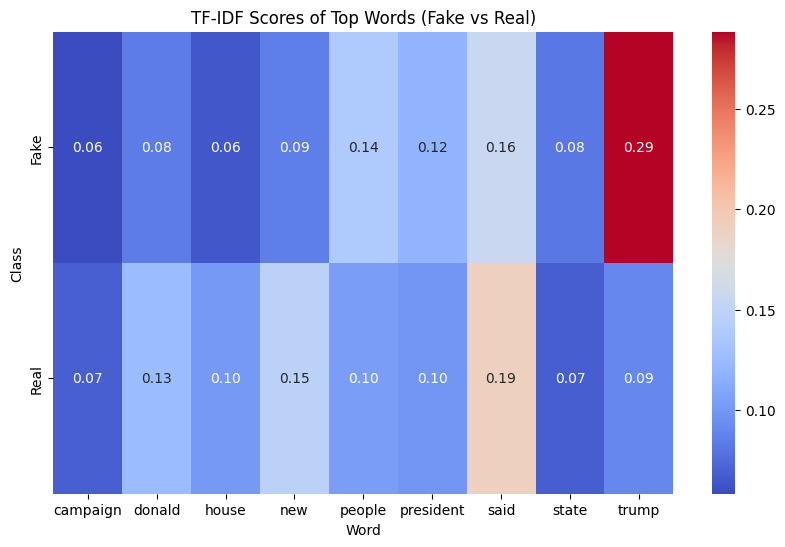

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=20, stop_words='english')
tfidf_matrix = tfidf.fit_transform(data[data['label'] == 0]['clean_text'])  
fake_words = tfidf.get_feature_names_out()
tfidf_matrix_real = tfidf.fit_transform(data[data['label'] == 1]['clean_text'])  
real_words = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame({
    'Fake': tfidf_matrix.mean(axis=0).A1,
    'Real': tfidf_matrix_real.mean(axis=0).A1
}, index=fake_words)
tfidf_df = tfidf_df.loc[tfidf_df.index.intersection(real_words)]
plt.figure(figsize=(10, 6))
sns.heatmap(tfidf_df.T, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("TF-IDF Scores of Top Words (Fake vs Real)")
plt.xlabel("Word")
plt.ylabel("Class")
plt.show()

# average word length calculation

C:\Users\Sanga\anaconda3\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


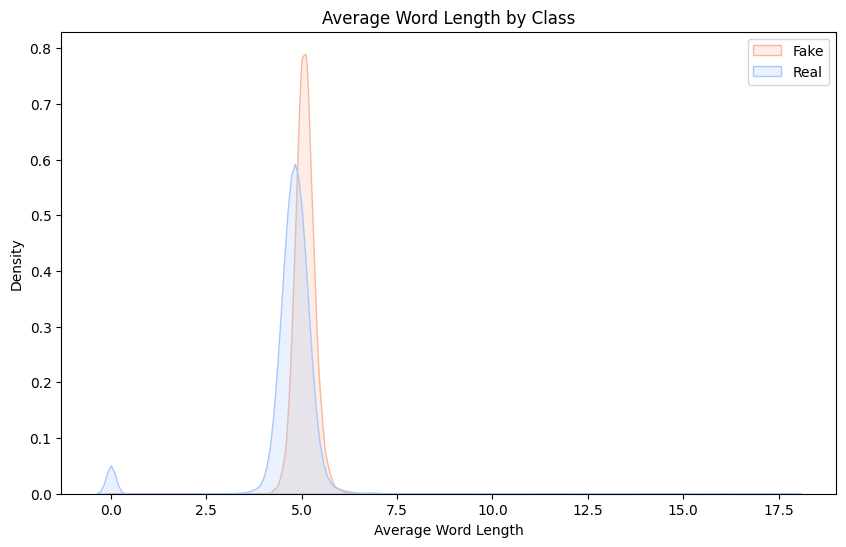

In [47]:
def compute_avg_word_length(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)
data['avg_word_length'] = data['clean_text'].apply(compute_avg_word_length)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='avg_word_length', hue='label', fill=True, palette='coolwarm')
plt.title("Average Word Length by Class")
plt.xlabel("Average Word Length")
plt.ylabel("Density")
plt.legend(labels=['Fake', 'Real'])
plt.show()

# length of article by class

C:\Users\Sanga\anaconda3\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Sanga\anaconda3\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Sanga\anaconda3\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


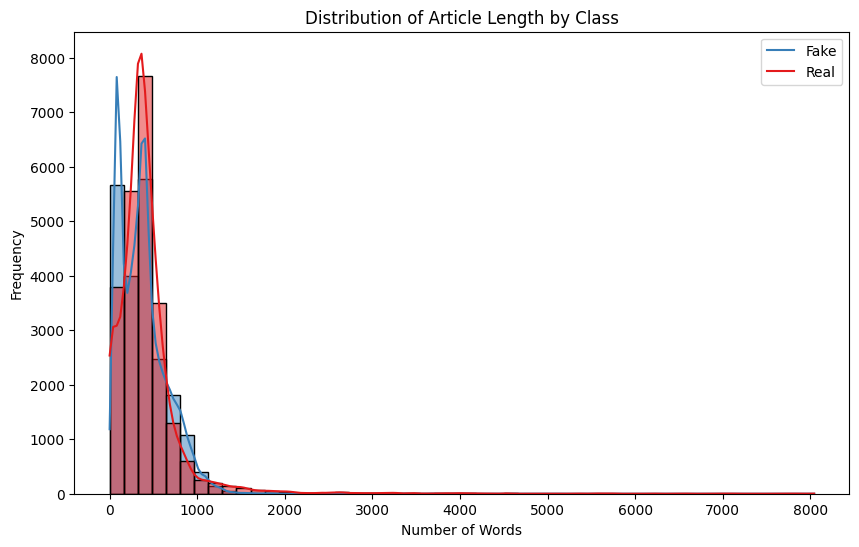

In [49]:
data['text_length'] = data['clean_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='text_length', hue='label', bins=50, kde=True, palette='Set1')
plt.title("Distribution of Article Length by Class")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend(labels=['Fake', 'Real'])
plt.show()